# 03 — Junior (all) vs Senior (all): Citations & Publications

**Goal:** Compare award-winning Junior authors vs award-winning Senior authors on citation and
publication output. h-index and i10-index are DROPPED from this comparison — they are cumulative,
snapshot-at-query-time metrics, and since award years span 2000-2018, some authors have had up to
26 years to accumulate stats vs as few as 8 years for others. Raw h-index/i10 would mostly measure
"time since award," not career stage, so they are not usable here without heavy correction.

**Metrics used instead:**
- `cited_by_count` and `works_count` — same time-confound problem, so we report BOTH the raw
  cumulative values (for descriptive context) AND a time-normalized rate
  (`cited_by_count / years_since_first_pub`, `works_count / years_since_first_pub`) as the primary
  comparison metric.
- All group means are reported with 95% confidence intervals (bootstrap), not bare averages.
- Group difference tested with Mann-Whitney U (distributions are expected to be right-skewed).


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

np.random.seed(42)
DATA_DIR = Path('../conf_data')
FIG_DIR = Path('../conf_figures')
FIG_DIR.mkdir(exist_ok=True)

CURRENT_YEAR = 2026

df = pd.read_csv(DATA_DIR / '02_award_authors_with_career_stage.csv')
print(df.shape)
df['career_stage'].value_counts(dropna=False)


(3150, 14)


career_stage
Senior    2313
Junior     828
NaN          9
Name: count, dtype: int64

## Step 1 — Clean: drop unresolved career stage

In [2]:
before = len(df)
df = df[df['career_stage'].notna()].copy()
print(f"Dropped {before - len(df)} rows with unresolved career_stage (9 authors, per notebook 02 log)")
print(df['career_stage'].value_counts())
print(f"\nUnique authors: {df['author_id'].nunique()}")


Dropped 9 rows with unresolved career_stage (9 authors, per notebook 02 log)
career_stage
Senior    2313
Junior     828
Name: count, dtype: int64

Unique authors: 2701


## Step 2 — Time-normalize citations & publications

`years_since_first_pub = CURRENT_YEAR - first_pub_year`. This is the exposure window each author
has had to accumulate citations/works, independent of when they won their award.


In [3]:
df['years_since_first_pub'] = CURRENT_YEAR - df['first_pub_year']
df = df[df['years_since_first_pub'] > 0].copy()

df['citations_per_year'] = df['cited_by_count'] / df['years_since_first_pub']
df['works_per_year'] = df['works_count'] / df['years_since_first_pub']

df[['author_name', 'career_stage', 'first_pub_year', 'years_since_first_pub',
    'cited_by_count', 'citations_per_year', 'works_count', 'works_per_year']].head()


,author_name,career_stage,first_pub_year,years_since_first_pub,cited_by_count,citations_per_year,works_count,works_per_year
0,Chenjun Xiao,Senior,2012.0,14.0,224.0,16.000000,47.0,3.357143
1,Jincheng Mei,Junior,2014.0,12.0,248.0,20.666667,29.0,2.416667
2,Martin Müller,Senior,1966.0,60.0,3116.0,51.933333,164.0,2.733333
3,John Hale,Senior,1930.0,96.0,4539.0,47.281250,86.0,0.895833
4,Chris Dyer,Senior,1970.0,56.0,34435.0,614.910714,370.0,6.607143


**Note:** This analysis is at the author-paper-pair level (2,710 unique authors but each row is an
author x award-paper pair, so authors with multiple award papers appear multiple times). For this
notebook we deduplicate to one row per unique author, since career-stage/citation metrics are
author-level, not paper-level, to avoid double-counting.


In [4]:
author_level = df.drop_duplicates(subset='author_id').copy()
print(f"Rows before dedup: {len(df)}, after dedup to unique authors: {len(author_level)}")
author_level['career_stage'].value_counts()


Rows before dedup: 3141, after dedup to unique authors: 2701


career_stage
Senior    1941
Junior     760
Name: count, dtype: int64

## Step 3 — Bootstrap confidence intervals helper

In [5]:
def bootstrap_ci(data, n_boot=5000, ci=95):
    data = data.dropna().values
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    boot_means = np.array([
        np.mean(np.random.choice(data, size=len(data), replace=True))
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100 - (100-ci)/2)
    return np.mean(data), lower, upper

metrics = ['cited_by_count', 'citations_per_year', 'works_count', 'works_per_year']
summary_rows = []
for metric in metrics:
    for stage in ['Junior', 'Senior']:
        subset = author_level.loc[author_level['career_stage'] == stage, metric]
        mean, lo, hi = bootstrap_ci(subset)
        summary_rows.append({
            'metric': metric, 'career_stage': stage, 'n': subset.notna().sum(),
            'mean': mean, 'ci_lower': lo, 'ci_upper': hi, 'median': subset.median()
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(DATA_DIR / '03_junior_vs_senior_summary.csv', index=False)
summary_df


,metric,career_stage,n,mean,ci_lower,ci_upper,median
0,cited_by_count,Junior,760,2214.850000,1876.206447,2628.945592,767.500000
1,cited_by_count,Senior,1941,11821.450799,10644.658269,13104.509480,4885.000000
2,citations_per_year,Junior,760,123.939832,106.740352,144.735636,50.916667
3,citations_per_year,Senior,1941,352.810205,309.393671,401.686084,144.652174
4,works_count,Junior,760,47.948684,43.365691,53.209112,23.000000
5,works_count,Senior,1941,204.624936,195.387738,214.210046,151.000000
6,works_per_year,Junior,760,2.841601,2.584466,3.114827,1.446023
7,works_per_year,Senior,1941,5.932906,5.679875,6.201372,4.500000


## Step 4 — Statistical tests (Mann-Whitney U)

In [6]:
test_rows = []
for metric in metrics:
    j = author_level.loc[author_level['career_stage'] == 'Junior', metric].dropna()
    s = author_level.loc[author_level['career_stage'] == 'Senior', metric].dropna()
    stat, p = stats.mannwhitneyu(j, s, alternative='two-sided')
    test_rows.append({'metric': metric, 'n_junior': len(j), 'n_senior': len(s), 'U_stat': stat, 'p_value': p})

test_df = pd.DataFrame(test_rows)
test_df.to_csv(DATA_DIR / '03_mannwhitney_results.csv', index=False)
test_df


,metric,n_junior,n_senior,U_stat,p_value
0,cited_by_count,760,1941,271447.5,2.801837e-144
1,citations_per_year,760,1941,426004.0,1.592486e-65
2,works_count,760,1941,209718.0,1.886444e-184
3,works_per_year,760,1941,382740.0,1.981630e-84


## Step 5 — Visualizations with error bars

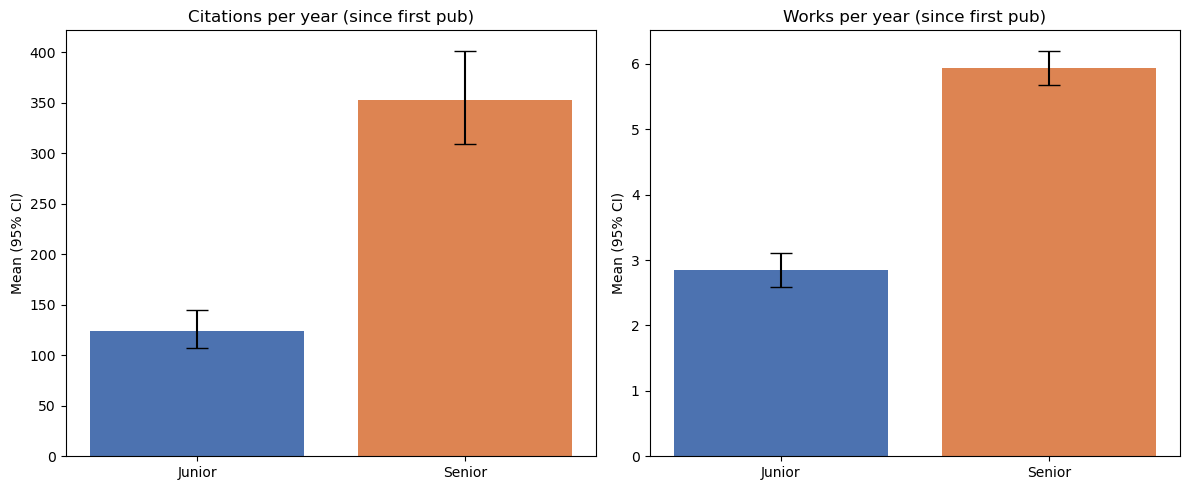

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, metric, title in zip(axes, ['citations_per_year', 'works_per_year'],
                              ['Citations per year (since first pub)', 'Works per year (since first pub)']):
    sub = summary_df[summary_df['metric'] == metric]
    means = sub['mean'].values
    errs_lower = means - sub['ci_lower'].values
    errs_upper = sub['ci_upper'].values - means
    ax.bar(sub['career_stage'], means, yerr=[errs_lower, errs_upper], capsize=8, color=['#4C72B0', '#DD8452'])
    ax.set_title(title)
    ax.set_ylabel('Mean (95% CI)')

plt.tight_layout()
plt.savefig(FIG_DIR / '03_junior_vs_senior_rates_bar.png', dpi=150)
plt.show()


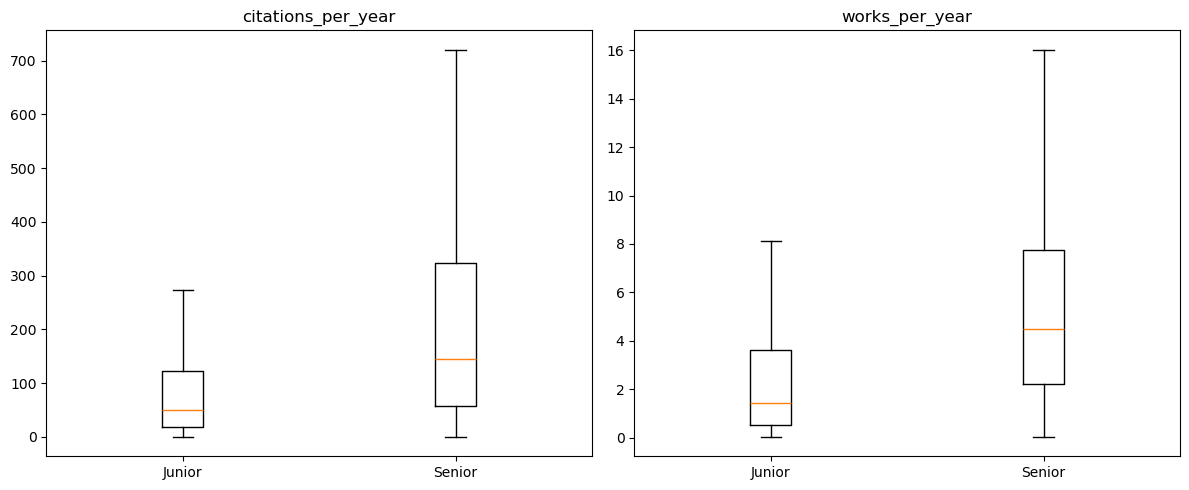

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, metric in zip(axes, ['citations_per_year', 'works_per_year']):
    data_j = author_level.loc[author_level['career_stage']=='Junior', metric].dropna()
    data_s = author_level.loc[author_level['career_stage']=='Senior', metric].dropna()
    ax.boxplot([data_j, data_s], labels=['Junior', 'Senior'], showfliers=False)
    ax.set_title(metric)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_junior_vs_senior_boxplots.png', dpi=150)
plt.show()


## Interpretation notes

- Raw cumulative `cited_by_count`/`works_count` are reported for descriptive context only
  (in `03_junior_vs_senior_summary.csv`) but should NOT be used to claim juniors "achieve less" —
  they've simply had less time.
- `citations_per_year` and `works_per_year` are the fairer comparison since both groups are
  normalized by their own career exposure window.
- Check `03_mannwhitney_results.csv` for significance; report p-values alongside effect direction,
  not just significance stars.


## Data Provenance Log Update

In [9]:
log_path = DATA_DIR / '00_data_sources_log.md'

junior_n = (author_level['career_stage']=='Junior').sum()
senior_n = (author_level['career_stage']=='Senior').sum()

new_entries = [
    "",
    "## Notebook 03 — Junior (all) vs Senior (all): citations & publications",
    f"- Input: 02_award_authors_with_career_stage.csv ({len(pd.read_csv(DATA_DIR / '02_award_authors_with_career_stage.csv'))} rows).",
    "- Dropped 9 rows with unresolved career_stage (per notebook 02 log).",
    f"- Deduplicated to unique-author level for this analysis: {len(author_level)} authors "
    f"(Junior={junior_n}, Senior={senior_n}).",
    "- DROPPED h-index and i10-index from comparison: both are cumulative snapshot-at-query-time "
    "metrics, confounded by award year spanning 2000-2018 (8 to 26 years of accumulation time).",
    "- Added time-normalized metrics: citations_per_year and works_per_year "
    "(= cited_by_count / years_since_first_pub, works_count / years_since_first_pub) as primary "
    "comparison metrics; raw cumulative counts kept for descriptive context only.",
    "- All group means reported with bootstrap 95% CIs (5000 resamples), not bare averages.",
    "- Group differences tested via Mann-Whitney U (two-sided) given expected right-skewed distributions.",
    "- LIMITATION: still author-level only (not per-award-paper); an author with multiple award "
    "papers is counted once here based on their own overall career metrics.",
    "",
    "### Output files",
    "- conf_data/03_junior_vs_senior_summary.csv — means, 95% CIs, medians, n per group/metric",
    "- conf_data/03_mannwhitney_results.csv — significance tests per metric",
    "- conf_figures/03_junior_vs_senior_rates_bar.png — bar chart with error bars",
    "- conf_figures/03_junior_vs_senior_boxplots.png — distribution boxplots",
]

with open(log_path, 'a') as f:
    f.write("\n".join(new_entries))

print("Log updated.")


Log updated.
